# 머신러닝 실습 : 고객 구매 데이터로 성별 예측 모델링 (분류 문제)

- 주어진 데이터는 백화점 고객의 1년 간 구매 데이터입니다.
- 고객 3,500명에 대한 학습용 데이터(y.csv, X.csv)를 이용하여 성별예측 모형을 만들어보세요.
- 모델의 성능은 자유롭게 측정해봅니다!

[실습 프로세스]
1. 데이터 불러오기
2. 데이터 탐색
3. 데이터 전처리
4. 학습/테스트 데이터 분리
5. 모델 선택 및 학습
6. 예측 및 평가

# 0. 라이브러리 불러오기

- 라이브러리를 가져와서 과정을 준비합니다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings(action='ignore')

# 1. 데이터 불러오기

- 데이터를 가져와서 과정을 준비합시다.
- 인코딩 방식은 'euc-kr' 을 활용하세요.
- 데이터 출처 : 한국데이터산업진흥원 빅데이터분석기사 실기 공개 예시 문항
- 독립 변수 데이터셋 : ./data/X.csv
- 종속 변수 데이터셋 : ./data/y.csv

데이터 파일을 불러옵니다. 보통 CSV 파일을 pandas로 읽어옵니다.

In [2]:
import os
# 노트북 파일이 있는 폴더로 이동 (예시)
os.chdir(r'C:\Users\Admin\hipython\ml')

# 변경 후 확인
# print("변경 후:", os.getcwd())

In [3]:
X = pd.read_csv('./data/X.csv', encoding='euc-kr')
y = pd.read_csv('./data/y.csv', encoding='euc-kr')

In [5]:
X.head()

,cust_id,총구매액,최대구매액,환불금액,주구매상품,주구매지점,내점일수,내점당구매건수,주말방문비율,구매주기
0,0,68282840,11264000,6860000.0,기타,강남점,19,3.894737,0.527027,17
1,1,2136000,2136000,300000.0,스포츠,잠실점,2,1.500000,0.000000,1
2,2,3197000,1639000,NaN,남성 캐주얼,관악점,2,2.000000,0.000000,1
3,3,16077620,4935000,NaN,기타,광주점,18,2.444444,0.318182,16
4,4,29050000,24000000,NaN,보석,본 점,2,1.500000,0.000000,85


In [6]:
y.head()

,cust_id,gender
0,0,0
1,1,0
2,2,1
3,3,1
4,4,0


# 2. 데이터 탐색하기

- 데이터를 이해할 수 있도록 탐색과정을 수행해봅시다.
- 데이터의 상위 몇 개 행을 출력하여 전체 구조를 미리 확인합니다.
- 데이터의 요약 정보나 통계 정보를 출력해 변수들의 유형과 분포를 확인합니다.

1. 전체 데이터프레임 확인: 행/열수, 데이터 타입
2. str(범주형) 변수 > 분포 확인

In [7]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cust_id  3500 non-null   int64  
 1   총구매액     3500 non-null   int64  
 2   최대구매액    3500 non-null   int64  
 3   환불금액     1205 non-null   float64
 4   주구매상품    3500 non-null   str    
 5   주구매지점    3500 non-null   str    
 6   내점일수     3500 non-null   int64  
 7   내점당구매건수  3500 non-null   float64
 8   주말방문비율   3500 non-null   float64
 9   구매주기     3500 non-null   int64  
dtypes: float64(3), int64(5), str(2)
memory usage: 273.6 KB


In [8]:
X['주구매상품'].unique()

<StringArray>
[    '기타',    '스포츠', '남성 캐주얼',     '보석',   '디자이너',   '시티웨어',     '명품',
    '농산물',    '화장품',     '골프',     '구두',   '가공식품',    '수산품',     '아동',
   '차/커피',    '캐주얼',   '섬유잡화',     '육류',   '축산가공',  '젓갈/반찬',   '액세서리',
   '피혁잡화',   '일용잡화',   '주방가전',   '주방용품',   '건강식품',     '가구',     '주류',
  '모피/피혁', '남성 트랜디',     '셔츠',   '남성정장',   '생활잡화',  '트래디셔널', '란제리/내의',
    '커리어',  '침구/수예',   '대형가전', '통신/컴퓨터',     '식기',   '소형가전',     '악기']
Length: 42, dtype: str

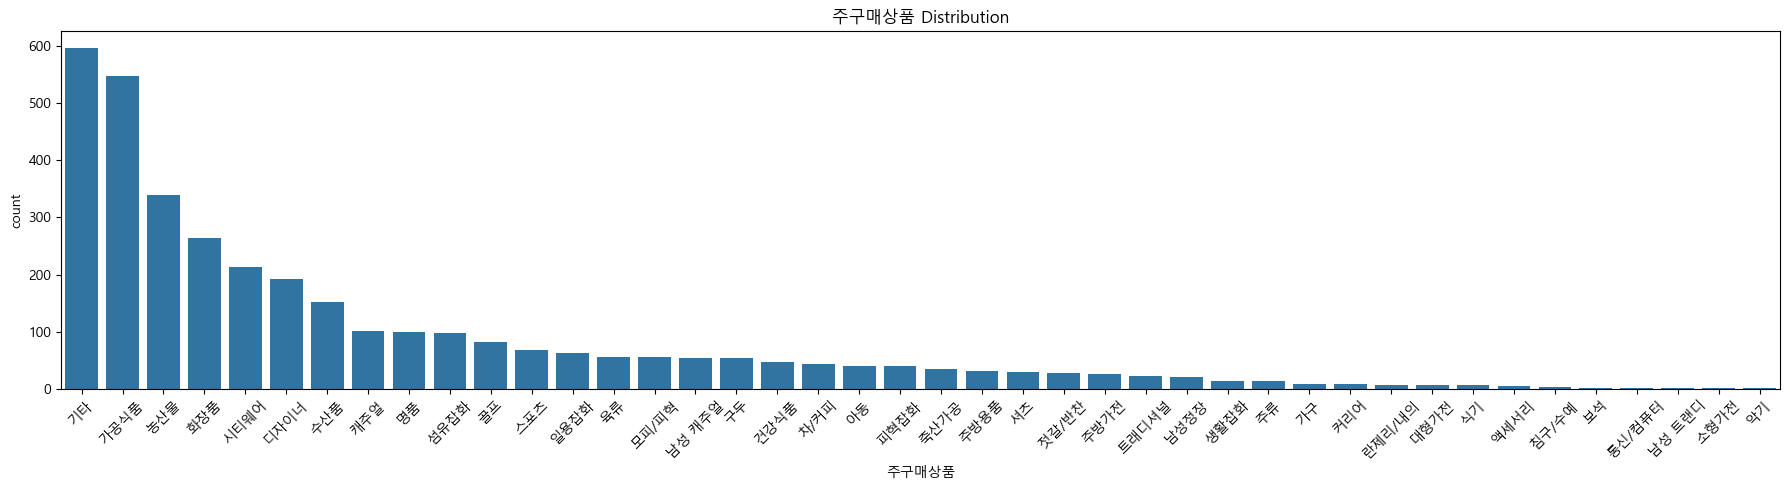

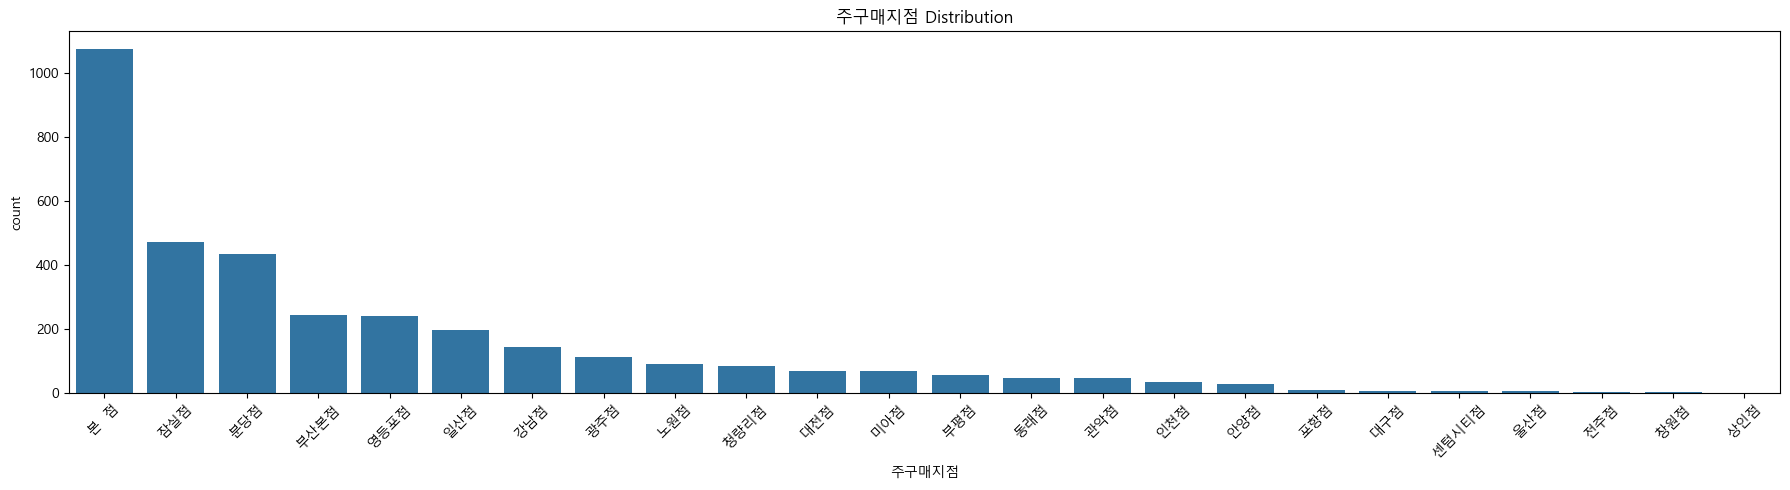

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

categorical_cols = ['주구매상품', '주구매지점']

for col in categorical_cols:
    plt.figure(figsize=(18,5))
    sns.countplot(data=X, x=col, order=X[col].value_counts().index)
    plt.title(f'{col} Distribution')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [10]:
X['주구매지점'].unique()

<StringArray>
[  '강남점',   '잠실점',   '관악점',   '광주점',  '본  점',   '일산점',   '대전점',  '부산본점',
   '분당점',  '영등포점',   '미아점',  '청량리점',   '안양점',   '부평점',   '동래점',   '포항점',
   '노원점',   '창원점', '센텀시티점',   '인천점',   '대구점',   '전주점',   '울산점',   '상인점']
Length: 24, dtype: str

In [13]:
X['주구매상품'].value_counts()

주구매상품
기타        595
가공식품      546
농산물       339
화장품       264
시티웨어      213
디자이너      193
수산품       153
캐주얼       101
명품        100
섬유잡화       98
골프         82
스포츠        69
일용잡화       64
육류         57
모피/피혁      57
남성 캐주얼     55
구두         54
건강식품       47
차/커피       44
아동         40
피혁잡화       40
축산가공       35
주방용품       32
셔츠         30
젓갈/반찬      29
주방가전       26
트래디셔널      23
남성정장       22
생활잡화       15
주류         14
가구         10
커리어         9
란제리/내의      8
대형가전        8
식기          7
액세서리        5
침구/수예       4
보석          3
통신/컴퓨터      3
남성 트랜디      2
소형가전        2
악기          2
Name: count, dtype: int64

In [16]:
X['주구매지점'].value_counts()

주구매지점
본  점     1077
잠실점       474
분당점       436
부산본점      245
영등포점      241
일산점       198
강남점       145
광주점       114
노원점        90
청량리점       86
대전점        70
미아점        69
부평점        57
동래점        49
관악점        46
인천점        34
안양점        29
포항점        11
대구점         7
센텀시티점       6
울산점         6
전주점         5
창원점         4
상인점         1
Name: count, dtype: int64

In [18]:
X.describe()

,cust_id,총구매액,최대구매액,환불금액,내점일수,내점당구매건수,주말방문비율,구매주기
count,3500.000000,3.500000e+03,3.500000e+03,1.205000e+03,3500.000000,3500.000000,3500.000000,3500.000000
mean,1749.500000,9.191925e+07,1.966424e+07,2.407822e+07,19.253714,2.834963,0.307246,20.958286
std,1010.507298,1.635065e+08,3.199235e+07,4.746453e+07,27.174942,1.912368,0.289752,24.748682
min,0.000000,-5.242152e+07,-2.992000e+06,5.600000e+03,1.000000,1.000000,0.000000,0.000000
25%,874.750000,4.747050e+06,2.875000e+06,2.259000e+06,2.000000,1.666667,0.027291,4.000000
50%,1749.500000,2.822270e+07,9.837000e+06,7.392000e+06,8.000000,2.333333,0.256410,13.000000
75%,2624.250000,1.065079e+08,2.296250e+07,2.412000e+07,25.000000,3.375000,0.448980,28.000000
max,3499.000000,2.323180e+09,7.066290e+08,5.637530e+08,285.000000,22.083333,1.000000,166.000000


In [19]:
X.isnull().sum()

cust_id       0
총구매액          0
최대구매액         0
환불금액       2295
주구매상품         0
주구매지점         0
내점일수          0
내점당구매건수       0
주말방문비율        0
구매주기          0
dtype: int64

In [ ]:
X.skew(numeric_only=True)

cust_id    0.000000
총구매액       4.170487
최대구매액      6.109304
환불금액       4.917401
내점일수       2.818757
내점당구매건수    2.954445
주말방문비율     0.940755
구매주기       2.096728
dtype: float64